# 02 — Narrative Visualization

> **"Data tells you what happened. Narrative tells you why it matters."**

---

Một chart nếu chỉ hiển thị số liệu thì người xem phải tự suy luận ý nghĩa.
**Narrative Visualization** là kỹ thuật nhúng câu chuyện trực tiếp vào trong chart:
đánh dấu khi nào mọi thứ thay đổi, tại sao nó thay đổi, và giai đoạn nào là quan trọng.

### Nội dung notebook này:

1. **Turning Points** — Phát hiện và đánh dấu đỉnh / đáy tự động
2. **Event Markers** — Gắn sự kiện lịch sử lên trục thời gian
3. **Timeline Bands** — Tô màu các giai đoạn (phase / regime)
4. **Regime Shading** — Phân vùng hệ thống theo breakpoints
5. **Story Frames** — Cấu trúc hóa narrative thành các frame
6. **Narrative Caption** — Thêm takeaway text dưới chart
7. **NarrativePipeline** — Pipeline hoàn chỉnh từ data đến story

## Setup

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.use('Agg')
%matplotlib inline

import sys, os
sys.path.insert(0, os.path.abspath('../src'))

from vizint.core import ChartBuilder, despine, set_grid
from vizint.perception import highlight_series, fade_series
from vizint.narrative import (
    mark_turning_points,
    add_event_markers,
    add_timeline_band,
    shade_regimes,
    add_regime_labels,
    StoryFrame,
    add_narrative_caption,
)
from vizint.annotation import label_last_point, add_note, annotate_with_arrow
from vizint.pipeline import NarrativePipeline

np.random.seed(7)
print('Setup OK ✓')

Setup OK ✓


## Synthetic Data — Vietnam GDP Growth (simulated)

Dữ liệu giả lập tăng trưởng GDP theo quý trong 15 năm (2009–2024).
Gồm 4 giai đoạn rõ ràng:
- **Recovery** (2009–2012): phục hồi sau khủng hoảng tài chính
- **Stable Growth** (2012–2019): tăng trưởng ổn định
- **Crisis** (2020–2021): COVID-19
- **Rebound** (2022–2024): phục hồi mạnh

In [2]:
# Quarterly data: 2009 Q1 → 2024 Q4  (64 quarters)
n_quarters = 64
quarters   = np.arange(n_quarters)

# Simulate GDP growth rate (%)
def make_gdp_series(seed=7):
    rng = np.random.default_rng(seed)
    y = np.zeros(n_quarters)
    # Phase 1: Recovery 2009-2012 (Q0-Q15)
    y[:16]  = 5.5 + np.linspace(0, 1.5, 16) + rng.normal(0, 0.4, 16)
    # Phase 2: Stable Growth 2012-2019 (Q16-Q43)
    y[16:44] = 6.8 + rng.normal(0, 0.5, 28)
    # Phase 3: COVID Crisis 2020-2021 (Q44-Q51)
    y[44:52] = np.array([3.8, 0.4, -6.1, -4.5, 4.5, 5.6, 5.2, 5.8])
    # Phase 4: Rebound 2022-2024 (Q52-Q63)
    y[52:]   = 7.2 + np.linspace(0, -0.8, 12) + rng.normal(0, 0.4, 12)
    return y

y_gdp = make_gdp_series()

# Quarter labels for x-axis ticks
year_ticks  = [i for i in range(n_quarters) if i % 4 == 0]
year_labels = [str(2009 + i // 4) for i in year_ticks]

# Key events
EVENTS = [
    (12,  'Basel III'),
    (28,  'TPP signed'),
    (44,  'COVID-19'),
    (52,  'Recovery plan'),
]

# Regime breakpoints (quarter index)
BREAKPOINTS = [16, 44, 52]
REGIME_LABELS = ['Recovery', 'Stable Growth', 'COVID Crisis', 'Rebound']

print(f'Quarters: {n_quarters}  |  GDP range: [{y_gdp.min():.1f}%, {y_gdp.max():.1f}%]')

Quarters: 64  |  GDP range: [-6.1%, 7.7%]


## 1. Turning Points

**Turning Point** = điểm mà xu hướng **đảo chiều cục bộ** trong time series.
Bao gồm:

- **Local Maximum (Peak)** — đỉnh cục bộ
- **Local Minimum (Trough)** — đáy cục bộ

Turning points giúp:

- Detect trend reversal
- Segment regimes
- Identify cycles / oscillations
- Highlight support & resistance
- Reduce visual noise when analyzing signals

---

## Mathematical Definition

Cho time series:

$$
x_1, x_2, x_3, \dots, x_n
$$

Một điểm $x_i$ là **local maximum** nếu:

$$
x_i > x_{i-k}, \dots, x_{i-1}
\quad \text{and} \quad
x_i > x_{i+1}, \dots, x_{i+k}
$$

Một điểm $x_i$ là **local minimum** nếu:

$$
x_i < x_{i-k}, \dots, x_{i-1}
\quad \text{and} \quad
x_i < x_{i+1}, \dots, x_{i+k}
$$

Trong đó:

$$
k = \text{order}
$$

`order` định nghĩa kích thước **local window**.

---

## Role of `order`

`order` kiểm soát **độ nhạy phát hiện turning points**

### Small order

$$
k \downarrow
$$

- nhạy hơn
- bắt nhiều turning points
- dễ nhiễu
- phù hợp signal dao động nhanh

### Large order

$$
k \uparrow
$$

- ít turning points
- chỉ giữ đảo chiều lớn
- ổn định hơn
- phù hợp trend dài

---

## Visual Intuition

`order = 1`

$$
[x_{i-1}, x_i, x_{i+1}]
$$

so sánh với **2 neighbors**

→ rất nhạy
→ nhiều peak giả

---

`order = 5`

$$
[x_{i-5}, \dots, x_i, \dots, x_{i+5}]
$$

so sánh với **10 neighbors**

→ chỉ giữ turning point lớn
→ smooth hơn

---

## Relationship to Derivative

Turning point xảy ra khi **đạo hàm đổi dấu**

Continuous case:

$$
f'(x) = 0
$$

Discrete approximation:

$$
x_{i+1} - x_i
$$

Turning point khi:

$$
(x_i - x_{i-1})(x_{i+1} - x_i) < 0
$$

Tức là slope đổi dấu.

`argrelextrema` thực chất là **generalized derivative sign change**
nhưng dùng window thay vì chỉ 2 điểm.

---

## Algorithm (argrelextrema idea)

For each point:

$$
x_i
$$

Check:

Peak:

$$
x_i = \max(x_{i-k}, \dots, x_{i+k})
$$

Trough:

$$
x_i = \min(x_{i-k}, \dots, x_{i+k})
$$

Complexity:

$$
O(nk)
$$

---

## Noise Sensitivity

Time series có noise:

$$
x_t = s_t + \epsilon_t
$$

với:

- $s_t$ : signal thật
- $\epsilon_t$ : noise

Nếu `order` nhỏ:

noise tạo nhiều peak giả

Nếu `order` lớn:

lọc noise tốt hơn

---

## Heuristic for Choosing `order`

Rule of thumb:

Short series:

$$
order = 2 \sim 3
$$

Medium:

$$
order = 5 \sim 10
$$

Long series:

$$
order \approx 0.01 n
$$

Periodic signal:

$$
order \approx \frac{period}{4}
$$

---

## With Smoothing (Recommended)

Thường nên smooth trước khi detect:

Moving average:

$$
\tilde{x}_t =
\frac{1}{m}
\sum_{i=-m}^{m} x_{t+i}
$$

Hoặc Gaussian smoothing:

$$
\tilde{x}_t =
\sum w_i x_{t+i}
$$

Sau đó detect turning points trên:

$$
\tilde{x}_t
$$

→ giảm false peaks

---

## First vs Second Order Turning Points

First-order turning points
→ peak nhỏ

Second-order turning points
→ peak lớn hơn

Có thể lặp:

detect turning points → detect tiếp trên peaks

Giống multi-scale analysis.

---

## Use Cases

### Trend reversal detection

Detect:

$$
\uparrow \to \downarrow
$$

### Cycle detection

Peak → trough → peak

### Regime segmentation

Split series tại turning points

### Financial support/resistance

Local max → resistance
Local min → support

### Oscillation detection

Sine-like signal:

$$
x = \sin(t)
$$

Turning points = crest & trough

---

## Edge Effects

Biên của series:

$$
x_1, x_2, \dots, x_k
$$

không thể kiểm tra đầy đủ window

→ bị bỏ qua

Do cần:

$$
k \text{ points before and after}
$$

---

## Practical Notes

- turning points ≠ global extrema
- nhạy với noise
- nên combine smoothing
- nên combine threshold filtering
- nên combine prominence filtering

---

## Optional: Prominence Filtering

Chỉ giữ turning points lớn:

$$
|x_i - x_{prev}| > \tau
$$

hoặc:

$$
|x_i - x_{next}| > \tau
$$

→ loại peak nhỏ

---

## Summary

Turning point:

$$
\text{local extrema in window}
$$

Controlled by:

$$
order
$$

Small:

$$
more\ peaks
$$

Large:

$$
major\ peaks
$$

Best practice:

smooth → detect → filter

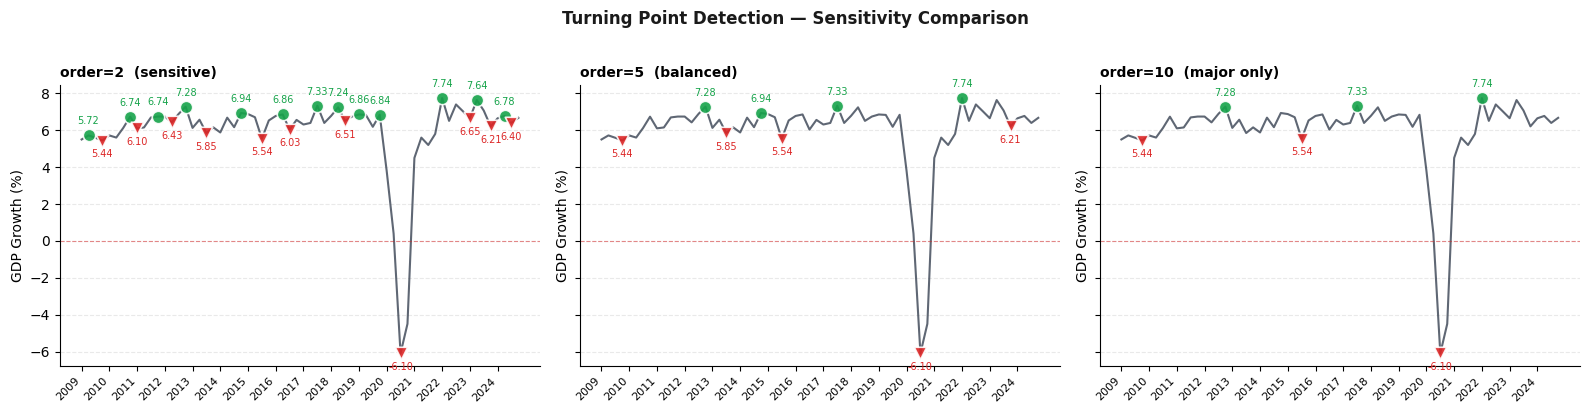

In [3]:
# So sánh order khác nhau
fig, axes = plt.subplots(1, 3, figsize=(16, 4), facecolor='white', sharey=True)

for ax, order, title in zip(
    axes,
    [2, 5, 10],
    ['order=2  (sensitive)', 'order=5  (balanced)', 'order=10  (major only)']
):
    ax.plot(quarters, y_gdp, color='#374151', linewidth=1.5, alpha=0.8)
    ax.axhline(0, color='#DC2626', linewidth=0.8, linestyle='--', alpha=0.5)
    mark_turning_points(ax, quarters, y_gdp, order=order,
                        max_color='#16A34A', min_color='#DC2626',
                        show_labels=True, label_fontsize=7)
    ax.set_xticks(year_ticks)
    ax.set_xticklabels(year_labels, rotation=45, ha='right', fontsize=8)
    ax.set_title(title, loc='left', fontsize=10, fontweight='bold')
    ax.set_ylabel('GDP Growth (%)')
    despine(ax); set_grid(ax)

fig.suptitle('Turning Point Detection — Sensitivity Comparison',
             fontsize=12, fontweight='bold', color='#1a1a1a', y=1.02)
plt.tight_layout()
plt.show()

Ba biểu đồ sử dụng cùng một time series nhưng khác `order`:

- `order = 2` → sensitive
- `order = 5` → balanced
- `order = 10` → major only

---

## Interpretation

### order = 2 (Sensitive)

Window nhỏ:

$$
k = 2
$$

So sánh:

$$
[x_{i-2}, x_{i-1}, x_i, x_{i+1}, x_{i+2}]
$$

Đặc điểm:

- phát hiện nhiều turning points
- bắt cả dao động nhỏ
- dễ nhiễu
- nhiều local peaks giả

Phù hợp:

- oscillatory signal
- short-term fluctuation
- cycle detection

---

### order = 5 (Balanced)

Window trung bình:

$$
k = 5
$$

So sánh:

$$
[x_{i-5}, \dots, x_i, \dots, x_{i+5}]
$$

Đặc điểm:

- loại bỏ noise nhỏ
- giữ turning points quan trọng
- cân bằng sensitivity / stability

Đây thường là **default tốt nhất**

---

### order = 10 (Major Only)

Window lớn:

$$
k = 10
$$

Đặc điểm:

- chỉ giữ đảo chiều lớn
- bỏ qua fluctuation nhỏ
- rất stable
- ít turning points

Phù hợp:

- long-term trend
- regime change detection
- macro signal

---

## Sensitivity vs Stability Tradeoff

Turning point count:

$$
k \downarrow \Rightarrow N_{points} \uparrow
$$

$$
k \uparrow \Rightarrow N_{points} \downarrow
$$

Noise sensitivity:

$$
k \downarrow \Rightarrow noise\ sensitivity \uparrow
$$

$$
k \uparrow \Rightarrow noise\ sensitivity \downarrow
$$

---

## Practical Heuristic

Short noisy series:

$$
order = 2 \sim 4
$$

Medium macro series:

$$
order = 5 \sim 8
$$

Long trend series:

$$
order = 10 \sim 20
$$

---

## Multi-Scale Turning Points

Có thể detect nhiều scale:

Small scale:

$$
order = 2
$$

Medium scale:

$$
order = 5
$$

Large scale:

$$
order = 10
$$

Union:

$$
TP = TP_2 \cup TP_5 \cup TP_{10}
$$

→ hierarchical turning points

---

## Key Takeaway

`order` điều khiển **scale của turning points**

Small:

$$
local\ fluctuations
$$

Medium:

$$
meaningful\ reversals
$$

Large:

$$
major\ regime\ changes
$$

Best practice:

$$
detect(order=2,5,10)
$$

→ so sánh sensitivity

## 2. Event Markers

**Event Markers** = các **đường dọc (vertical lines)** đánh dấu thời điểm xảy ra sự kiện quan trọng trên time series.

Mục tiêu: giúp người xem hiểu **nguyên nhân** khiến series thay đổi tại một thời điểm cụ thể.

Ví dụ:

- policy change
- crisis
- product launch
- anomaly start
- regime shift
- intervention
- structural break

---

## Mathematical Representation

Time series:

$$
x_t, \quad t = 1,2,\dots,n
$$

Event xảy ra tại:

$$
t = t_e
$$

Event marker là đường dọc:

$$
x = t_e
$$

Tức là vẽ:

$$
\{(t_e, y) \mid y \in [y_{min}, y_{max}] \}
$$

---

## Multiple Events

Nếu có nhiều events:

$$
E = \{t_1, t_2, t_3, \dots, t_k\}
$$

Ta vẽ:

$$
x = t_i \quad \forall i
$$

---

## Event Label Placement

Label được đặt gần đỉnh axes:

$$
y = y_{max}
$$

Rotate:

$$
\theta = 90^\circ
$$

Mục tiêu:

- tránh che data
- tránh overlap
- dễ đọc timeline

---

## Visual Interpretation

Event marker tạo **causal reference**

Trước event:

$$
x_{t < t_e}
$$

Sau event:

$$
x_{t > t_e}
$$

So sánh:

$$
\Delta = E[x_{after}] - E[x_{before}]
$$

Nếu:

$$
\Delta \neq 0
$$

→ event có ảnh hưởng

---

## Event vs Turning Point

Turning point:

$$
detected\ from\ data
$$

Event marker:

$$
provided\ by\ user
$$

Turning point = endogenous
Event marker = exogenous

---

## Structural Break Detection

Event marker giúp kiểm tra:

$$
H_0: \mu_{before} = \mu_{after}
$$

$$
H_1: \mu_{before} \neq \mu_{after}
$$

Mean shift:

$$
\mu_1 = E[x_{t<t_e}]
$$

$$
\mu_2 = E[x_{t>t_e}]
$$

Nếu:

$$
|\mu_1 - \mu_2| > 0
$$

→ structural change

---

## Regime Segmentation

Event chia series thành 2 regimes:

Before:

$$
R_1 = [1, t_e]
$$

After:

$$
R_2 = [t_e, n]
$$

Nhiều events:

$$
R_1, R_2, R_3, \dots
$$

---

## When to Use

Use event markers khi:

- explain sudden drop
- explain spike
- mark anomaly start
- mark intervention
- mark policy change
- mark crisis
- mark regime shift

---

## Common Examples

Economic crisis:

$$
t = 2020
$$

COVID shock

Policy change:

$$
t = t_{policy}
$$

Model deployment:

$$
t = t_{deploy}
$$

---

## Styling Principles

Vertical line:

$$
linestyle = "--"
$$

Color:

$$
\alpha < 1
$$

Label:

$$
rotation = 90^\circ
$$

Position:

$$
y = y_{max}
$$

---

## Multiple Events Spacing

Nếu events gần nhau:

offset label:

$$
y_i = y_{max} - i\delta
$$

để tránh overlap

---

## Event + Turning Point

Combine:

Turning point:

$$
data\ driven
$$

Event:

$$
knowledge\ driven
$$

Nếu:

event ≈ turning point

→ causal evidence

---

## Summary

Event marker:

$$
x = t_e
$$

Purpose:

$$
explain\ why\ change\ happens
$$

Turning point:

$$
where\ change\ happens
$$

Event marker:

$$
why\ change\ happens
$$

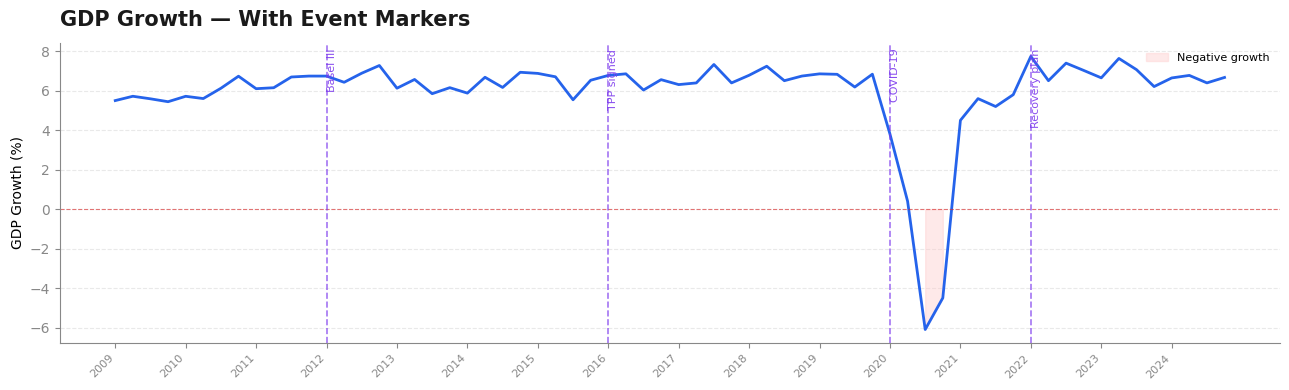

In [4]:
chart = (
    ChartBuilder(figsize=(13, 4))
    .set_title('GDP Growth — With Event Markers')
    .build()
)
ax = chart.ax

ax.plot(quarters, y_gdp, color='#2563EB', linewidth=2.0)
ax.axhline(0, color='#DC2626', linewidth=0.8, linestyle='--', alpha=0.6)
ax.fill_between(quarters, y_gdp, 0,
                where=(y_gdp < 0), color='#FECACA', alpha=0.4, label='Negative growth')

# Event markers
event_x, event_labels = zip(*EVENTS)
add_event_markers(
    ax,
    x_positions=event_x,
    labels=list(event_labels),
    color='#7C3AED',
    linewidth=1.2,
    linestyle='--',
    label_fontsize=8,
    label_rotation=90,
)

ax.set_xticks(year_ticks)
ax.set_xticklabels(year_labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('GDP Growth (%)')
ax.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()

Trong biểu đồ, các events chính:

- Brexit
- TPP signing
- COVID-19 shock
- Recovery period

Các marker này giúp liên hệ:

$$
event \rightarrow change\ in\ series
$$

Thay vì chỉ thấy turning point, người xem hiểu **tại sao** series thay đổi.

---

## COVID-19 — Structural Break

Tại marker COVID:

$$
t = 2020
$$

GDP giảm mạnh:

$$
\Delta x \ll 0
$$

So sánh mean:

Before:

$$
\mu_{before} \approx 6.5
$$

During shock:

$$
x_{min} \approx -6
$$

Đây là:

- structural break
- regime change
- outlier lớn

---

## Recovery — Regime Shift

Sau marker recovery:

$$
t \approx 2022
$$

GDP quay lại mức trước đó:

$$
x_t \approx 6.5 \sim 7.5
$$

Biểu đồ chia thành 3 regimes:

Pre-COVID:

$$
R_1 = [2009, 2019]
$$

Crash:

$$
R_2 = [2020, 2021]
$$

Recovery:

$$
R_3 = [2022, 2024]
$$

---

## Brexit & TPP — Weak Impact

Tại các markers:

- Brexit
- TPP signing

Series chỉ dao động nhỏ:

$$
|\Delta x| \approx small
$$

Không có:

- turning point lớn
- structural break
- regime change

=> impact yếu lên GDP

---

## Event vs Turning Point

Nếu:

$$
event \approx turning\ point
$$

→ causal evidence mạnh

Nếu:

$$
event \neq turning\ point
$$

→ impact yếu hoặc delayed

Trong biểu đồ:

- COVID → trùng turning point
- Brexit → không trùng
- TPP → không trùng

---

## Zero Line Interpretation

Đường:

$$
y = 0
$$

Biểu diễn:

- tăng trưởng dương
- tăng trưởng âm

Chỉ có COVID:

$$
x_t < 0
$$

=> khủng hoảng hiếm và nghiêm trọng

---

## Key Takeaways

Event markers giúp:

- giải thích spike / drop
- xác định structural break
- so sánh before vs after
- đánh giá causal impact

Trong biểu đồ này:

- COVID → major structural break
- Recovery → regime shift
- Brexit → minor impact
- TPP → minor impact

## 3. Timeline Bands

**Timeline Band** = vùng tô màu biểu diễn **một giai đoạn kéo dài theo thời gian** trên time series.

Khác với event marker (1 thời điểm), timeline band thể hiện:

- policy period
- crisis window
- intervention period
- campaign duration
- regime phase
- experiment window

---

## Mathematical Representation

Time series:

$$
x_t, \quad t = 1,2,\dots,n
$$

Timeline band được xác định bởi:

$$
[t_{start}, t_{end}]
$$

Band là vùng:

$$
\{(t, y) \mid t \in [t_{start}, t_{end}],\; y \in [y_{min}, y_{max}] \}
$$

Tức là một **vertical shaded region**.

---

## Visual Meaning

Timeline band giúp phân tích:

Before band:

$$
t < t_{start}
$$

During band:

$$
t_{start} \le t \le t_{end}
$$

After band:

$$
t > t_{end}
$$

So sánh:

$$
\mu_{before},\ \mu_{during},\ \mu_{after}
$$

Nếu:

$$
\mu_{during} \neq \mu_{before}
$$

→ band có ảnh hưởng lên series

---

## Label Placement

Label thường đặt ở trung tâm band:

$$
t_{label} = \frac{t_{start}+t_{end}}{2}
$$

Theo trục y:

$$
y = y_{max}
$$

Mục tiêu:

- dễ đọc
- không che data
- gắn với period

---

## Event Marker vs Timeline Band

Event marker:

$$
t = t_e
$$

→ một thời điểm

Timeline band:

$$
t \in [t_1, t_2]
$$

→ một giai đoạn

---

## Use Together

Có thể combine:

Event:

$$
t = t_e
$$

Band:

$$
[t_1, t_2]
$$

Ví dụ:

COVID band:

$$
[2020, 2021]
$$

Lockdown event:

$$
t = 2020.25
$$

→ band + marker cùng tồn tại

---

## Structural Regime Example

Timeline band chia series thành:

Before:

$$
R_1 = [1, t_{start})
$$

During:

$$
R_2 = [t_{start}, t_{end}]
$$

After:

$$
R_3 = (t_{end}, n]
$$

---

## Typical Use Cases

Policy period:

$$
[t_{policy\_start}, t_{policy\_end}]
$$

Crisis window:

$$
[t_{crisis}, t_{recovery}]
$$

Training period:

$$
[t_{train\_start}, t_{train\_end}]
$$

Experiment window:

$$
[t_A, t_B]
$$

---

## Multiple Bands

Nếu có nhiều regimes:

$$
B_1, B_2, B_3
$$

Ta có:

$$
[t_1,t_2],\ [t_3,t_4],\ [t_5,t_6]
$$

Giúp visualize multi-phase system.

---

## Styling Principles

Transparency:

$$
\alpha < 0.3
$$

để không che data

Band color:

$$
color = muted
$$

Label position:

$$
center\ of\ band
$$

---

## Timeline Band + Turning Points

Nếu turning points nằm trong band:

$$
t_{tp} \in [t_1,t_2]
$$

→ band có thể gây change

Nếu ngoài band:

$$
t_{tp} \notin [t_1,t_2]
$$

→ band không phải nguyên nhân

---

## Summary

Timeline band:

$$
[t_{start}, t_{end}]
$$

Event marker:

$$
t = t_e
$$

Event marker:

- thời điểm
- sudden change

Timeline band:

- giai đoạn
- sustained effect

Best practice:

use both together

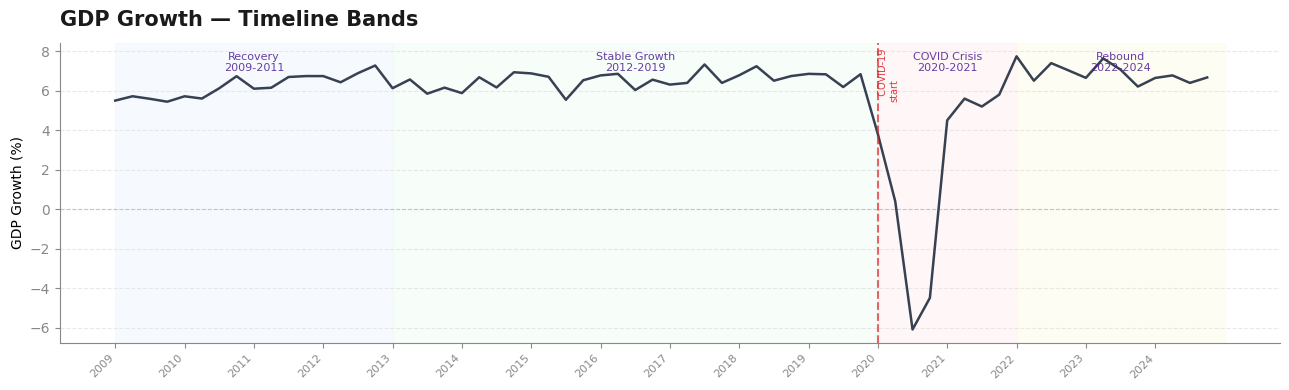

In [5]:
chart = (
    ChartBuilder(figsize=(13, 4))
    .set_title('GDP Growth — Timeline Bands')
    .build()
)
ax = chart.ax

ax.plot(quarters, y_gdp, color='#374151', linewidth=1.8, zorder=3)
ax.axhline(0, color='#9CA3AF', linewidth=0.8, linestyle='--', alpha=0.5)

# Bands cho từng giai đoạn
band_defs = [
    (0,  16, 'Recovery\n2009-2011',  '#EFF6FF', 0.5),
    (16, 44, 'Stable Growth\n2012-2019', '#F0FDF4', 0.5),
    (44, 52, 'COVID Crisis\n2020-2021',  '#FFF1F2', 0.6),
    (52, 64, 'Rebound\n2022-2024',       '#FEFCE8', 0.5),
]

for xmin, xmax, label, color, alpha in band_defs:
    add_timeline_band(ax, xmin, xmax, label=label,
                      color=color, alpha=alpha,
                      label_y=0.97, label_fontsize=8)

# Event markers chồng lên bands
add_event_markers(ax, [44], ['COVID-19\nstart'], color='#DC2626',
                  linewidth=1.5, label_fontsize=7)

ax.set_xticks(year_ticks)
ax.set_xticklabels(year_labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('GDP Growth (%)')

plt.tight_layout()
plt.show()

Timeline bands chia time series thành các **regimes kéo dài theo thời gian**, giúp phân tích **sustained effects** thay vì chỉ thay đổi tại một điểm.

Các bands trong biểu đồ:

- Recovery (2009–2011)
- Stable Growth (2012–2019)
- COVID Crisis (2020–2021)
- Rebound (2022–2024)

---

## Regime Segmentation

Timeline bands chia series thành 4 regimes:

Recovery:

$$
R_1 = [2009, 2011]
$$

Stable growth:

$$
R_2 = [2012, 2019]
$$

COVID crisis:

$$
R_3 = [2020, 2021]
$$

Rebound:

$$
R_4 = [2022, 2024]
$$

---

## Recovery Phase (2009–2011)

GDP tăng dần từ:

$$
x \approx 5.5 \rightarrow 6.8
$$

Đặc điểm:

- tăng trưởng ổn định
- volatility thấp
- post-recession recovery

Mean:

$$
\mu_{R_1} \approx 6.2
$$

---

## Stable Growth (2012–2019)

Đây là regime dài nhất:

$$
R_2 = 2012 \rightarrow 2019
$$

GDP dao động:

$$
6.0 \le x_t \le 7.3
$$

Đặc điểm:

- growth ổn định
- variance thấp
- không có structural break

Mean:

$$
\mu_{R_2} \approx 6.7
$$

---

## COVID Crisis (2020–2021)

Band này thể hiện shock kéo dài:

$$
R_3 = [2020, 2021]
$$

GDP rơi mạnh:

$$
x_{min} \approx -6
$$

Mean giảm mạnh:

$$
\mu_{R_3} \ll \mu_{R_2}
$$

Đây là:

- structural break
- regime shift
- extreme volatility

---

## Rebound (2022–2024)

Sau crisis:

$$
R_4 = [2022, 2024]
$$

GDP phục hồi:

$$
x_t \approx 6.3 \sim 7.6
$$

Đặc điểm:

- recovery nhanh
- variance cao hơn pre-COVID
- peak mới xuất hiện

Mean:

$$
\mu_{R_4} \approx 6.9
$$

---

## Mean Comparison Across Regimes

So sánh:

$$
\mu_{R_1} < \mu_{R_2}
$$

$$
\mu_{R_3} \ll \mu_{R_2}
$$

$$
\mu_{R_4} \approx \mu_{R_2}
$$

Cho thấy:

- growth ổn định trước COVID
- crash mạnh trong COVID
- phục hồi về mức cũ

---

## Event Marker + Timeline Band

Đường đỏ:

COVID start:

$$
t = 2020
$$

Event marker đánh dấu **start**

Timeline band thể hiện **duration**

Event:

$$
t = t_e
$$

Band:

$$
[t_e, t_{end}]
$$

Hai loại bổ sung nhau.

---

## Volatility Comparison

Variance theo regime:

Recovery:

$$
\sigma_{R_1}^2 \text{ thấp}
$$

Stable:

$$
\sigma_{R_2}^2 \text{ thấp}
$$

COVID:

$$
\sigma_{R_3}^2 \text{ rất cao}
$$

Rebound:

$$
\sigma_{R_4}^2 \text{ trung bình}
$$

---

## Key Takeaways

Timeline bands giúp:

- chia regimes rõ ràng
- thấy sustained effects
- so sánh before / during / after
- highlight crisis window

Trong biểu đồ:

- 2012–2019 → stable regime
- 2020–2021 → crisis regime
- 2022–2024 → rebound regime
- COVID là regime break rõ nhất

## 4. Regime Shading

**Regime** = trạng thái của hệ thống trong một giai đoạn thời gian, nơi thống kê của series gần như **ổn định cục bộ**.

Một regime có thể có:

- mean khác
- variance khác
- trend khác
- volatility khác
- distribution khác

---

## Mathematical Definition

Time series:

$$
x_t, \quad t=1,\dots,n
$$

Chia thành các regimes:

$$
R_1, R_2, R_3, \dots, R_k
$$

với breakpoints:

$$
\tau_1, \tau_2, \dots, \tau_{k-1}
$$

Khi đó:

$$
R_1 = [1, \tau_1]
$$

$$
R_2 = [\tau_1, \tau_2]
$$

$$
R_k = [\tau_{k-1}, n]
$$

---

## Regime Assumption

Trong mỗi regime:

Mean ổn định:

$$
E[x_t] = \mu_j \quad t \in R_j
$$

Variance ổn định:

$$
Var(x_t) = \sigma_j^2
$$

Nhưng giữa regimes:

$$
\mu_i \ne \mu_j
$$

hoặc

$$
\sigma_i^2 \ne \sigma_j^2
$$

---

## Regime Shading

`shade_regimes` tự động tô xen kẽ theo breakpoints:

$$
[\tau_0, \tau_1], [\tau_1, \tau_2], [\tau_2, \tau_3]
$$

Alternating shading:

- regime 1 → light
- regime 2 → dark
- regime 3 → light
- regime 4 → dark

Mục tiêu:

- nhấn mạnh ranh giới regime
- không phụ thuộc màu semantics
- focus vào structure

---

## Label Placement

`add_regime_labels` đặt label ở giữa regime:

Center:

$$
t_j = \frac{\tau_{j-1}+\tau_j}{2}
$$

Label:

$$
(t_j, y_{max})
$$

---

## Timeline Band vs Regime Shading

Timeline band:

- semantic color
- manual range
- highlight specific period

Regime shading:

- alternating color
- automatic segmentation
- highlight boundaries

Timeline band:

$$
[t_1, t_2]
$$

Regime shading:

$$
[\tau_0,\tau_1],[\tau_1,\tau_2],...
$$

---

## Structural Break Interpretation

Regime boundary:

$$
t = \tau_j
$$

Nếu:

$$
\mu_{j+1} \ne \mu_j
$$

→ mean shift

Nếu:

$$
\sigma_{j+1}^2 \ne \sigma_j^2
$$

→ volatility shift

Nếu:

$$
trend_{j+1} \ne trend_j
$$

→ regime change

---

## Example: Economic Regimes

Expansion:

$$
\mu > 0
$$

Crisis:

$$
\mu \ll 0
$$

Recovery:

$$
\mu \uparrow
$$

Stable:

$$
\sigma^2 \text{ thấp}
$$

---

## Regime Detection Sources

Breakpoints có thể đến từ:

Turning points:

$$
\tau = t_{tp}
$$

Change-point detection:

$$
CUSUM
$$

Bayesian change point:

$$
P(\tau | data)
$$

Manual domain knowledge:

COVID:

$$
\tau = 2020
$$

---

## Alternating Shading Logic

Nếu regimes:

$$
R_1,R_2,R_3,R_4
$$

Color pattern:

$$
light,dark,light,dark
$$

Không encode semantics
Chỉ encode segmentation.

---

## Use Cases

Use regime shading khi:

- highlight structural breaks
- show macro regimes
- compare statistics across periods
- segment time series
- visualize change points

---

## Summary

Regime:

$$
x_t \sim D_j \quad t \in R_j
$$

Breakpoints:

$$
\tau_1,\tau_2,\dots
$$

Regime shading:

- alternating bands
- emphasize boundaries
- structure > meaning

Timeline band:

- semantic color
- meaning > structure

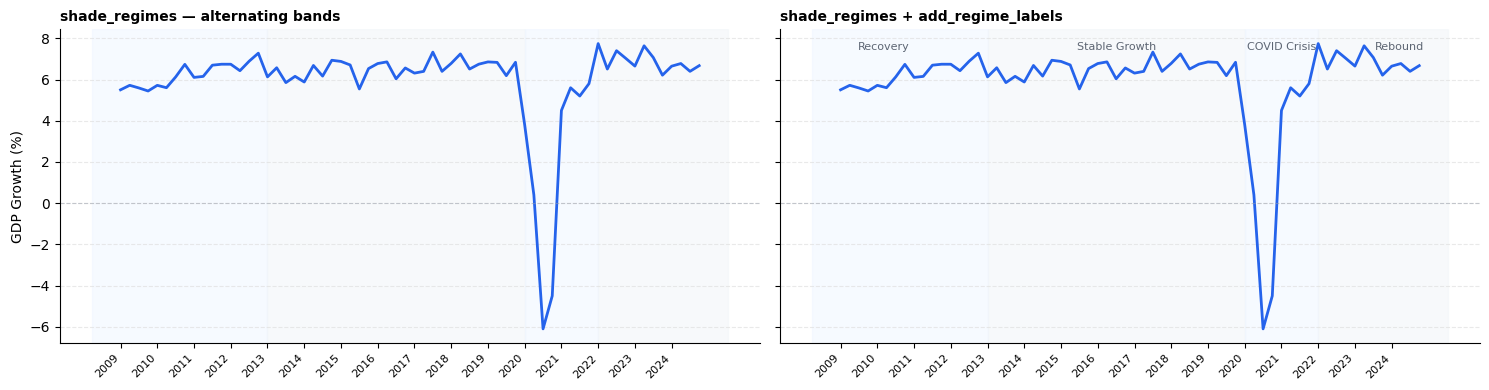

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4), facecolor='white', sharey=True)

# Panel 1: regime shading chỉ
ax = axes[0]
ax.plot(quarters, y_gdp, color='#2563EB', linewidth=2.0)
ax.axhline(0, color='#9CA3AF', linewidth=0.8, linestyle='--', alpha=0.5)
shade_regimes(ax, breakpoints=BREAKPOINTS,
              colors=['#EFF6FF', '#F1F5F9'], alpha=0.5)
ax.set_xticks(year_ticks)
ax.set_xticklabels(year_labels, rotation=45, ha='right', fontsize=8)
ax.set_title('shade_regimes — alternating bands', loc='left', fontsize=10, fontweight='bold')
ax.set_ylabel('GDP Growth (%)')
despine(ax); set_grid(ax)

# Panel 2: regime shading + labels
ax = axes[1]
ax.plot(quarters, y_gdp, color='#2563EB', linewidth=2.0)
ax.axhline(0, color='#9CA3AF', linewidth=0.8, linestyle='--', alpha=0.5)
shade_regimes(ax, breakpoints=BREAKPOINTS,
              colors=['#EFF6FF', '#F1F5F9'], alpha=0.5)
add_regime_labels(ax, breakpoints=BREAKPOINTS, labels=REGIME_LABELS,
                  y_position=0.96, fontsize=8, color='#374151')
ax.set_xticks(year_ticks)
ax.set_xticklabels(year_labels, rotation=45, ha='right', fontsize=8)
ax.set_title('shade_regimes + add_regime_labels', loc='left', fontsize=10, fontweight='bold')
despine(ax); set_grid(ax)

plt.tight_layout()
plt.show()

Regime shading tô **alternating bands** để nhấn mạnh **các giai đoạn có thống kê khác nhau** trong time series.
Không dùng màu để biểu diễn semantic, mà dùng để **làm rõ boundaries** giữa regimes.

Biểu đồ gồm hai phần:

- Left: `shade_regimes` — chỉ alternating bands
- Right: `shade_regimes + add_regime_labels` — thêm tên regime

---

## Regime Segmentation

Breakpoints chia series thành 4 regimes:

$$
\tau = \{2011, 2019, 2021\}
$$

Các regimes:

Recovery:

$$
R_1 = [2009, 2011]
$$

Stable Growth:

$$
R_2 = [2012, 2019]
$$

COVID Crisis:

$$
R_3 = [2020, 2021]
$$

Rebound:

$$
R_4 = [2022, 2024]
$$

---

## Statistical Interpretation

Mỗi regime có thống kê khác nhau:

Mean:

$$
\mu_j = E[x_t \mid t \in R_j]
$$

Variance:

$$
\sigma_j^2 = Var(x_t \mid t \in R_j)
$$

Nếu:

$$
\mu_i \ne \mu_j
$$

→ mean shift

Nếu:

$$
\sigma_i^2 \ne \sigma_j^2
$$

→ volatility shift

---

## Recovery Regime

GDP tăng dần:

$$
5.5 \rightarrow 6.8
$$

Đặc điểm:

- upward trend
- low volatility
- post-crisis recovery

$$
\mu_{R1} < \mu_{R2}
$$

---

## Stable Growth Regime

GDP ổn định:

$$
6.0 \le x_t \le 7.2
$$

Đặc điểm:

- stationary mean
- variance thấp
- regime dài nhất

$$
\sigma_{R2}^2 \text{ nhỏ}
$$

---

## COVID Crisis Regime

Regime ngắn nhưng extreme:

$$
x_{min} \approx -6
$$

Variance tăng mạnh:

$$
\sigma_{R3}^2 \gg \sigma_{R2}^2
$$

Mean shift:

$$
\mu_{R3} \ll \mu_{R2}
$$

Đây là **structural break rõ nhất**

---

## Rebound Regime

GDP phục hồi:

$$
6.3 \le x_t \le 7.7
$$

Đặc điểm:

- mean quay lại mức cũ
- volatility cao hơn stable period
- peak mới xuất hiện

$$
\mu_{R4} \approx \mu_{R2}
$$

---

## Alternating Bands Purpose

Alternating shading:

- không encode meaning
- chỉ highlight segmentation
- dễ nhìn boundaries

Pattern:

$$
light \rightarrow dark \rightarrow light \rightarrow dark
$$

Giúp thấy rõ:

$$
R_1 | R_2 | R_3 | R_4
$$

---

## Regime vs Timeline Band

Timeline band:

- semantic color
- manually defined
- explain period meaning

Regime shading:

- alternating color
- segmentation focus
- highlight structure

Timeline:

$$
meaning
$$

Regime shading:

$$
structure
$$

---

## Key Takeaways

Regime shading giúp:

- highlight structural breaks
- compare statistics giữa periods
- visualize regime transitions
- giảm phụ thuộc màu semantics

Trong biểu đồ:

- 2012–2019 → stable regime
- 2020–2021 → crisis regime
- 2022–2024 → rebound regime
- boundary 2020 là regime break lớn nhất

## 5. Story Frames

**StoryFrame** là cấu trúc dùng để **đóng gói narrative** cho một đoạn cụ thể trên time series.
Mỗi frame tương ứng với **một câu chuyện + một vùng thời gian + series cần highlight**.

Khác với:

- Event marker → đánh dấu 1 thời điểm
- Timeline band → tô một giai đoạn
- Regime shading → chia trạng thái hệ thống
- **Story frame → kể câu chuyện gắn với dữ liệu**

---

## Structure

```python
StoryFrame(
    title   = 'COVID Shock',        # Headline ngắn
    body    = 'GDP giảm -6.1%...',  # Giải thích 1-3 câu
    xmin    = 44,                   # Bắt đầu giai đoạn
    xmax    = 52,                   # Kết thúc giai đoạn
    highlights = ['GDP'],           # Series liên quan
)
```

---

## Mathematical Representation

Frame định nghĩa một window:

$$
F = [x_{min}, x_{max}]
$$

Narrative mapping:

$$
F \rightarrow (title, body)
$$

Highlight region:

$$
x_t \quad t \in [x_{min}, x_{max}]
$$

---

## Fields

### title

Headline ngắn mô tả câu chuyện.

Ví dụ:

- COVID Shock
- Growth Slowdown
- Recovery Phase
- Policy Intervention

---

### body

Phần narrative giải thích:

- nguyên nhân
- diễn biến
- hậu quả

Ví dụ:

GDP giảm mạnh do lockdown toàn cầu và gián đoạn chuỗi cung ứng.

---

### xmin, xmax

Define vùng highlight:

$$
[x_{min}, x_{max}]
$$

Frame chỉ highlight:

$$
t \in [xmin, xmax]
$$

---

### highlights

Danh sách series cần emphasize:

$$
S = \{s_1, s_2, \dots, s_k\}
$$

Nếu nhiều series:

- highlight nhiều lines
- emphasize biến quan trọng
- focus attention

---

## Narrative Segmentation

Story frames chia timeline thành các đoạn:

$$
F_1, F_2, F_3, F_4
$$

Ví dụ:

Recovery:

$$
F_1 = [2009, 2011]
$$

Stable growth:

$$
F_2 = [2012, 2019]
$$

COVID shock:

$$
F_3 = [2020, 2021]
$$

Rebound:

$$
F_4 = [2022, 2024]
$$

---

## Story Sequence

`build_story_sequence(frames)` tạo narrative theo thứ tự:

$$
F_1 \rightarrow F_2 \rightarrow F_3 \rightarrow F_4
$$

Output:

- text summary
- ordered narrative
- presentation-ready explanation

---

## Visual Mapping

Frame tạo highlight:

$$
[t_{min}, t_{max}]
$$

Narrative text:

$$
(title, body)
$$

Mapping:

$$
frame \rightarrow region + explanation
$$

---

## Story Frame vs Regime

Regime:

$$
statistical\ segmentation
$$

Story frame:

$$
narrative\ segmentation
$$

Regime:

- data driven
- no explanation

Story frame:

- explanation driven
- storytelling

---

## Story Frame vs Timeline Band

Timeline band:

- highlight period

Story frame:

- explain period

Timeline band:

$$
visual
$$

Story frame:

$$
visual + narrative
$$

---

## Multi-Series Highlight

Nếu nhiều series:

$$
x_t^{(1)}, x_t^{(2)}
$$

Frame highlight:

$$
S = \{GDP, Inflation\}
$$

→ emphasize nhiều variables.

---

## Use Cases

Use story frames khi:

- build narrative visualization
- presentation charts
- dashboard storytelling
- explain anomalies
- explain regime change
- annotate model output

---

## Summary

StoryFrame:

$$
(title, body, xmin, xmax)
$$

Defines:

- narrative segment
- highlight region
- explanation text

Story sequence:

$$
F_1 \rightarrow F_2 \rightarrow F_3
$$

Purpose:

- storytelling
- explain data
- guide reader



In [7]:
from vizint.narrative.story import build_story_sequence

frames = [
    StoryFrame(
        title='Post-GFC Recovery',
        body='GDP growth rebounded steadily from 5.5% to 7%+ as trade recovered and domestic demand strengthened.',
        xmin=0, xmax=16,
        highlights=['GDP'],
    ),
    StoryFrame(
        title='Stable Growth Era',
        body='Seven years of consistent 6-7% growth driven by FDI inflows, export expansion, and structural reforms.',
        xmin=16, xmax=44,
        highlights=['GDP'],
    ),
    StoryFrame(
        title='COVID-19 Shock',
        body='Q3 2020 saw GDP contract to -6.1%, the steepest decline on record, before rapid containment measures took hold.',
        xmin=44, xmax=52,
        highlights=['GDP'],
    ),
    StoryFrame(
        title='Strong Rebound',
        body='Economic reopening and pent-up demand drove growth back above 7%, with recovery outpacing regional peers.',
        xmin=52, xmax=64,
        highlights=['GDP'],
    ),
]

# Print narrative sequence
for line in build_story_sequence(frames):
    print(line)
    print()

1. Post-GFC Recovery: GDP growth rebounded steadily from 5.5% to 7%+ as trade recovered and domestic demand strengthened.

2. Stable Growth Era: Seven years of consistent 6-7% growth driven by FDI inflows, export expansion, and structural reforms.

3. COVID-19 Shock: Q3 2020 saw GDP contract to -6.1%, the steepest decline on record, before rapid containment measures took hold.

4. Strong Rebound: Economic reopening and pent-up demand drove growth back above 7%, with recovery outpacing regional peers.



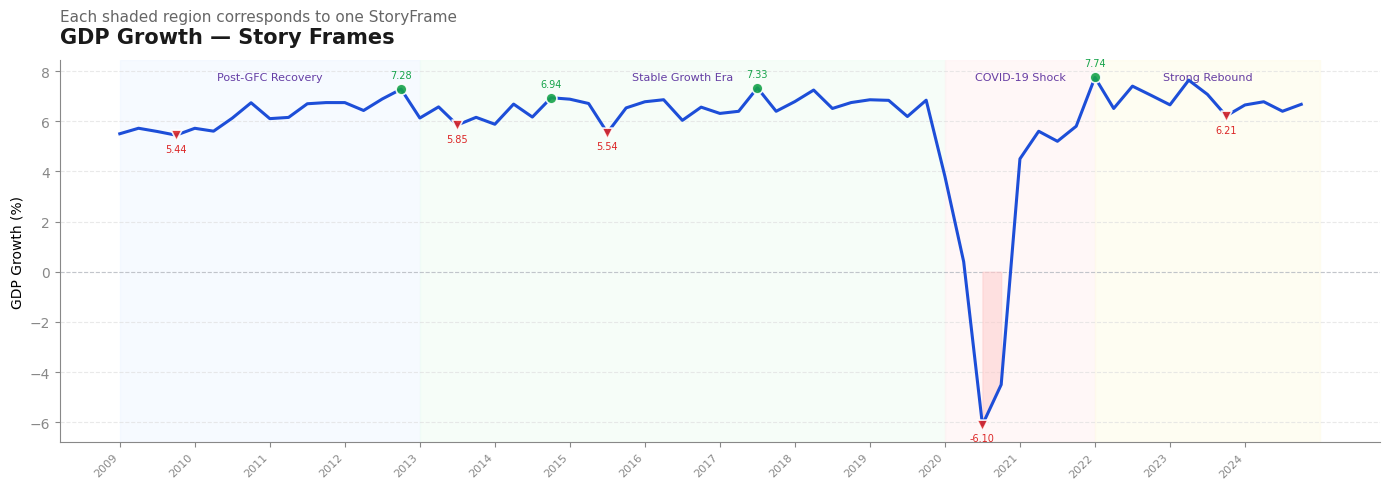

In [8]:
# Render story frames lên chart — mỗi frame = một vùng màu khác nhau
frame_colors = ['#EFF6FF', '#F0FDF4', '#FFF1F2', '#FEFCE8']
frame_border = ['#93C5FD', '#86EFAC', '#FCA5A5', '#FDE68A']

chart = (
    ChartBuilder(figsize=(14, 5))
    .set_title('GDP Growth — Story Frames')
    .set_subtitle('Each shaded region corresponds to one StoryFrame')
    .build()
)
ax = chart.ax

# Render each frame as a timeline band
for frame, fc, bc in zip(frames, frame_colors, frame_border):
    add_timeline_band(ax, frame.xmin, frame.xmax,
                      label=frame.title,
                      color=fc, alpha=0.55,
                      label_y=0.97, label_fontsize=8)

# Plot data on top
ax.plot(quarters, y_gdp, color='#1D4ED8', linewidth=2.2, zorder=5)
ax.axhline(0, color='#9CA3AF', linewidth=0.8, linestyle='--', alpha=0.5)
ax.fill_between(quarters, y_gdp, 0,
                where=(y_gdp < 0), color='#FECACA', alpha=0.5, zorder=4)

# Turning points
mark_turning_points(ax, quarters, y_gdp, order=6,
                    max_color='#16A34A', min_color='#DC2626',
                    show_labels=True, label_fontsize=7, size=60)

ax.set_xticks(year_ticks)
ax.set_xticklabels(year_labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('GDP Growth (%)')

plt.tight_layout()
plt.show()

Mỗi vùng tô màu tương ứng với **một StoryFrame**, mô tả một giai đoạn narrative của nền kinh tế.
Story frames giúp biến time series thành **một câu chuyện theo thời gian** thay vì chỉ là dữ liệu.

---

## Frame 1 — Post-GFC Recovery

GDP phục hồi ổn định sau khủng hoảng tài chính toàn cầu:

$$
5.5\% \rightarrow 7.0\%+
$$

Đặc điểm:

- trade phục hồi
- domestic demand tăng
- growth tăng đều
- volatility thấp

Mean tăng:

$$
\mu_{F1} \uparrow
$$

Đây là **recovery regime**.

---

## Frame 2 — Stable Growth Era

Giai đoạn tăng trưởng ổn định kéo dài:

$$
6\% \le x_t \le 7\%
$$

Động lực:

- FDI inflows
- export expansion
- structural reforms

Đặc điểm:

- mean ổn định
- variance thấp
- regime dài nhất

$$
\mu_{F2} \approx constant
$$

---

## Frame 3 — COVID-19 Shock

GDP giảm mạnh:

$$
x_{min} = -6.1\%
$$

Đây là mức giảm sâu nhất:

$$
\min(x_t)
$$

Đặc điểm:

- sudden collapse
- lockdown impact
- supply chain disruption
- demand shock

Variance tăng mạnh:

$$
\sigma_{F3}^2 \gg \sigma_{F2}^2
$$

Đây là **structural break**.

---

## Frame 4 — Strong Rebound

Sau reopening:

$$
x_t > 7\%
$$

Động lực:

- reopening economy
- pent-up demand
- export recovery

Đặc điểm:

- recovery nhanh
- peak mới xuất hiện
- growth vượt pre-COVID

Mean:

$$
\mu_{F4} \approx \mu_{F2}
$$

---

## Narrative Flow

Story sequence:

$$
Recovery \rightarrow Stable \rightarrow Shock \rightarrow Rebound
$$

Time segmentation:

$$
F_1 \rightarrow F_2 \rightarrow F_3 \rightarrow F_4
$$

---

## Structural Interpretation

Mean comparison:

$$
\mu_{F1} < \mu_{F2}
$$

$$
\mu_{F3} \ll \mu_{F2}
$$

$$
\mu_{F4} \approx \mu_{F2}
$$

Variance comparison:

$$
\sigma_{F3}^2 \text{ lớn nhất}
$$

---

## Key Takeaways

Story frames giúp:

- biến chart thành narrative
- giải thích từng giai đoạn
- highlight structural break
- mô tả recovery pattern

Trong biểu đồ:

- Post-GFC → recovery
- Stable Growth → long regime
- COVID → shock lớn nhất
- Rebound → phục hồi nhanh

## 6. Narrative Caption

**Narrative Caption** là dòng **takeaway chính** đặt dưới chart.
Đây là **ý quan trọng nhất** mà người xem cần nhớ sau khi nhìn visualization.

Caption không dùng để mô tả chart, mà dùng để **truyền đạt insight**.

---

## Caption vs Description

Description chỉ mô tả dữ liệu:

GDP dao động trong khoảng:

$$
[-6.1\%,\; 7.8\%]
$$

Không có insight.

---

Insight caption nêu kết luận:

GDP quay lại mức trước COVID trong:

$$
6\ quarters
$$

Đây là:

- conclusion
- interpretation
- takeaway

---

## Good Caption Principles

### 1. State Insight

Không mô tả:

$$
what\ chart\ shows
$$

Mà nói:

$$
what\ chart\ means
$$

---

### 2. Be Concise

Caption tốt:

- 1–2 câu
- trực tiếp
- không dài dòng

---

### 3. Use Numbers

Caption nên có:

$$
quantitative\ evidence
$$

Ví dụ:

- 6 quarters
- -6.1%
- 7.8%
- 2012–2019

---

## Example — Description (Bad)

GDP growth fluctuated between -6.1% and 7.8%.

Đây chỉ là:

$$
range\ summary
$$

Không có insight.

---

## Example — Insight (Good)

Despite the COVID shock, growth returned to pre-pandemic levels within 6 quarters.

Insight:

- nhấn mạnh recovery speed
- có số cụ thể
- có comparison

---

## Mathematical Insight Form

Shock:

$$
x_{min} = -6.1\%
$$

Recovery:

$$
x_t \rightarrow 7\%
$$

Time to recovery:

$$
\Delta t = 6\ quarters
$$

---

## Caption Types

### Recovery Insight

Shock → recovery nhanh

$$
recovery\ speed
$$

---

### Structural Break Insight

Trước và sau khác nhau

$$
\mu_{before} \ne \mu_{after}
$$

---

### Volatility Insight

Variance thay đổi

$$
\sigma_1^2 \ne \sigma_2^2
$$

---

### Trend Insight

Trend thay đổi

$$
trend_1 \ne trend_2
$$

---

## Caption Placement

Caption đặt:

- dưới chart
- font nhỏ hơn title
- italic hoặc muted color

Mục tiêu:

- đọc sau cùng
- nhớ lâu nhất

---

## Caption Template

Template:


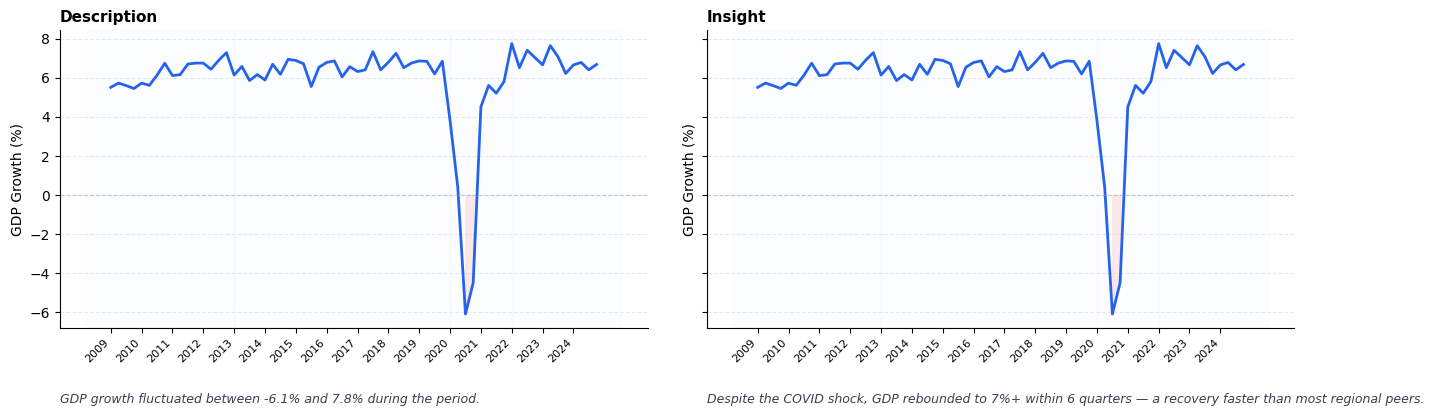

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), facecolor='white', sharey=True)

caption_bad  = "GDP growth fluctuated between -6.1% and 7.8% during the period."
caption_good = "Despite the COVID shock, GDP rebounded to 7%+ within 6 quarters — a recovery faster than most regional peers."

for ax, caption, tag in zip(axes, [caption_bad, caption_good], ['Description', 'Insight']):
    ax.plot(quarters, y_gdp, color='#2563EB', linewidth=2.0)
    ax.axhline(0, color='#9CA3AF', linewidth=0.8, linestyle='--', alpha=0.5)
    ax.fill_between(quarters, y_gdp, 0,
                    where=(y_gdp < 0), color='#FECACA', alpha=0.4)
    shade_regimes(ax, BREAKPOINTS, alpha=0.15)

    add_narrative_caption(ax, caption,
                          y=-0.22, fontsize=9,
                          color='#374151', style='italic')

    ax.set_xticks(year_ticks)
    ax.set_xticklabels(year_labels, rotation=45, ha='right', fontsize=8)
    ax.set_title(tag, loc='left', fontsize=11, fontweight='bold')
    ax.set_ylabel('GDP Growth (%)')
    despine(ax); set_grid(ax)

plt.tight_layout(pad=2.5)
plt.show()

Narrative caption là **takeaway cuối cùng** của visualization.
Hai biểu đồ minh họa sự khác biệt giữa **description** và **insight**.

---

## Description (Left)

Caption:

GDP growth fluctuated between:

$$
[-6.1\%,\; 7.8\%]
$$

Đây chỉ là:

- range summary
- descriptive statistics
- không có interpretation

Không trả lời:

- tại sao xảy ra
- điều gì quan trọng
- người xem nên nhớ gì

Description chỉ mô tả:

$$
what\ happened
$$

---

## Insight (Right)

Caption:

GDP phục hồi về:

$$
7\%+
$$

trong:

$$
6\ quarters
$$

Sau shock:

$$
x_{min} = -6.1\%
$$

Insight nhấn mạnh:

- recovery speed
- resilience
- comparison với peers

Insight trả lời:

$$
why\ it\ matters
$$

---

## Mathematical Comparison

Shock magnitude:

$$
S = -6.1\%
$$

Recovery level:

$$
R = 7\%
$$

Recovery time:

$$
\Delta t = 6\ quarters
$$

Insight:

$$
fast\ recovery
$$

---

## Information Content

Description chứa:

$$
range
$$

Insight chứa:

$$
range + interpretation + implication
$$

Information value:

$$
Insight > Description
$$

---

## Caption Quality Hierarchy

Bad:

GDP fluctuated between -6.1% and 7.8%.

Better:

GDP fell to -6.1% in 2020.

Best:

GDP recovered to 7% within 6 quarters after a -6.1% shock.

---

## Insight Pattern

Shock:

$$
x_{min}
$$

Recovery:

$$
x_t \rightarrow \mu
$$

Time:

$$
\Delta t
$$

Insight:

$$
fast\ recovery
$$

---

## Key Takeaways

Narrative caption nên:

- nêu insight
- không mô tả chart
- có số cụ thể
- ngắn gọn

Description:

$$
what\ happened
$$

Insight:

$$
why\ it\ matters
$$

## 7. Arrow Annotations

**Arrow Annotation** dùng để **gắn text giải thích trực tiếp vào một điểm dữ liệu cụ thể**.
Khác với caption (global insight), arrow annotation cung cấp **local insight**.

Use khi:

- explain outlier
- explain peak / trough
- explain anomaly
- highlight turning point
- attach short insight

---

## Mathematical Representation

Cho một điểm dữ liệu:

$$
(x_i, y_i)
$$

Annotation gồm:

- text position:

$$
(x_t, y_t)
$$

- arrow:

$$
(x_t, y_t) \rightarrow (x_i, y_i)
$$

Mapping:

$$
text \rightarrow data\ point
$$

---

## Local Insight

Arrow annotation giải thích:

$$
x_i = important\ point
$$

Ví dụ:

COVID shock:

$$
x_{2020} = -6.1\%
$$

Arrow:

- text: lockdown impact
- point: trough

---

## Connection Style

Tham số:
> connectionstyle = 'arc3,rad=X'


Điều khiển độ cong mũi tên:

---

### Straight Arrow

$$
rad = 0
$$

Đường thẳng:

- đơn giản
- dễ đọc
- dễ đè lên data

---

### Slight Curve

$$
rad = 0.2
$$

Cong nhẹ:

- tránh overlap
- readable
- default tốt

---

### Strong Curve

$$
rad = 0.4
$$

Cong rõ:

- tránh che data
- phù hợp dense chart
- highlight rõ hơn

---

## Visual Mapping

Arrow:

$$
(x_t,y_t) \rightarrow (x_i,y_i)
$$

Meaning:

$$
text\ explains\ point
$$

---

## Annotation Placement

Text thường đặt:

- phía trên peak
- phía dưới trough
- bên trái điểm
- bên phải điểm

Điều kiện:

$$
(x_t,y_t) \ne (x_i,y_i)
$$

để tránh overlap.

---

## Example — Peak Annotation

Peak:

$$
x_{max} = 7.8\%
$$

Arrow text:

Strong export growth

---

## Example — Trough Annotation

Trough:

$$
x_{min} = -6.1\%
$$

Arrow text:

COVID lockdown impact

---

## Arrow vs Event Marker

Event marker:

$$
x = t_e
$$

Arrow annotation:

$$
(x_i,y_i)
$$

Event marker:

- vertical line
- global context

Arrow:

- point specific
- local explanation

---

## Arrow vs Caption

Caption:

$$
global\ insight
$$

Arrow:

$$
local\ insight
$$

Caption:

- dưới chart

Arrow:

- trên chart

---

## Multiple Arrows

Nếu nhiều annotations:

$$
A_1, A_2, A_3
$$

Mỗi arrow:

$$
(x_{t_j},y_{t_j}) \rightarrow (x_{i_j},y_{i_j})
$$

Tránh overlap:

- dùng rad khác nhau
- đặt text khác vị trí

---

## Use Cases

Use arrow annotations khi:

- highlight extreme value
- explain sudden drop
- explain spike
- annotate model output
- add local insight

---

## Summary

Arrow annotation:

$$
text \rightarrow data\ point
$$

Connection:

$$
(x_t,y_t) \rightarrow (x_i,y_i)
$$

Purpose:

- explain specific point
- local insight
- highlight anomaly

Connection style:

$$
rad = 0,\ 0.2,\ 0.4
$$

→ control curvature

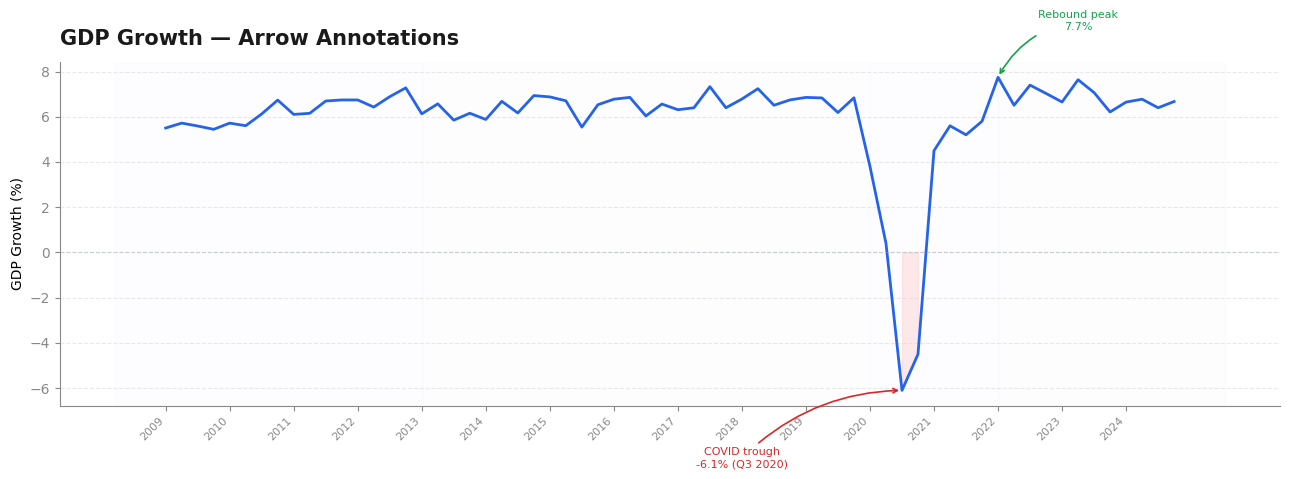

In [10]:
chart = (
    ChartBuilder(figsize=(13, 5))
    .set_title('GDP Growth — Arrow Annotations')
    .build()
)
ax = chart.ax

ax.plot(quarters, y_gdp, color='#2563EB', linewidth=2.0)
ax.axhline(0, color='#9CA3AF', linewidth=0.8, linestyle='--', alpha=0.4)
ax.fill_between(quarters, y_gdp, 0,
                where=(y_gdp < 0), color='#FECACA', alpha=0.4)

shade_regimes(ax, BREAKPOINTS, alpha=0.12)

# Tìm đáy COVID
covid_trough_idx = 44 + np.argmin(y_gdp[44:52])

# Annotate đáy COVID
annotate_with_arrow(
    ax,
    text=f'COVID trough\n{y_gdp[covid_trough_idx]:.1f}% (Q3 2020)',
    xy=(covid_trough_idx, y_gdp[covid_trough_idx]),
    xytext=(covid_trough_idx - 10, y_gdp[covid_trough_idx] - 3),
    fontsize=8,
    color='#DC2626',
    arrowcolor='#DC2626',
    connectionstyle='arc3,rad=-0.2',
    ha='center',
)

# Annotate peak rebound
rebound_peak_idx = 52 + np.argmax(y_gdp[52:])
annotate_with_arrow(
    ax,
    text=f'Rebound peak\n{y_gdp[rebound_peak_idx]:.1f}%',
    xy=(rebound_peak_idx, y_gdp[rebound_peak_idx]),
    xytext=(rebound_peak_idx + 5, y_gdp[rebound_peak_idx] + 2.5),
    fontsize=8,
    color='#16A34A',
    arrowcolor='#16A34A',
    connectionstyle='arc3,rad=0.25',
    ha='center',
)

ax.set_xticks(year_ticks)
ax.set_xticklabels(year_labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('GDP Growth (%)')

plt.tight_layout()
plt.show()

Arrow annotations dùng để **giải thích trực tiếp các điểm quan trọng** trên time series.
Trong biểu đồ có hai annotation chính:

- COVID trough
- Rebound peak

Mỗi annotation kết nối:

$$
text \rightarrow data\ point
$$

---

## COVID Trough Annotation

Điểm thấp nhất:

$$
x_{min} = -6.1\%
$$

Thời điểm:

$$
t = Q3\ 2020
$$

Annotation chỉ rõ:

- collapse đột ngột
- shock lớn nhất
- structural break

Mathematically:

$$
x_{2020} = \min(x_t)
$$

Đây là:

- outlier lớn
- regime change
- variance spike

---

## Rebound Peak Annotation

Sau shock, GDP đạt đỉnh:

$$
x_{peak} = 7.7\%
$$

Đặc điểm:

- recovery mạnh
- vượt mức pre-COVID
- demand rebound

Mathematically:

$$
x_{peak} > \mu_{pre}
$$

So sánh:

Pre-COVID mean:

$$
\mu \approx 6.7\%
$$

Rebound:

$$
7.7\% > 6.7\%
$$

---

## Recovery Magnitude

Shock:

$$
-6.1\%
$$

Rebound:

$$
7.7\%
$$

Biên độ recovery:

$$
\Delta = 7.7 - (-6.1)
$$

$$
\Delta = 13.8\%
$$

Đây là:

- large swing
- V-shaped recovery

---

## Curved Arrow Purpose

Mũi tên cong:

$$
rad > 0
$$

Giúp:

- tránh che data
- rõ ràng hơn
- highlight point

COVID annotation:

- cong xuống
- chỉ trough

Rebound annotation:

- cong lên
- chỉ peak

---

## Local Insight

Arrow annotations cung cấp:

COVID:

Shock sâu nhất lịch sử.

Rebound:

Recovery mạnh sau reopening.

Đây là:

$$
local\ explanation
$$

---

## Arrow vs Caption

Arrow:

- giải thích điểm cụ thể
- local insight

Caption:

- tổng kết toàn chart
- global insight

Arrow:

$$
point\ specific
$$

Caption:

$$
global\ takeaway
$$

---

## Key Takeaways

Arrow annotations giúp:

- highlight peak
- highlight trough
- giải thích anomaly
- nhấn mạnh recovery

Trong biểu đồ:

- COVID trough → -6.1%
- rebound peak → 7.7%
- recovery dạng chữ V rõ ràng

---
## 8. NarrativePipeline — Full Storytelling in One Call

`NarrativePipeline` là high-level class kết hợp tất cả layer của narrative:

```
Regime shading
    → Background series (faded)
        → Signal series (highlighted)
            → Mean reference
                → Turning points
                    → Event markers
                        → Caption
```


---

## Layered Narrative Architecture

Pipeline tổ chức visualization theo thứ tự:

### 1. Regime Shading (Context)

Chia timeline thành regimes:

$$
R_1, R_2, R_3, R_4
$$

Tạo **structural context**.

---

### 2. Background Series (Faded)

Series nền:

$$
x_t^{bg}
$$

Style:

- faded color
- alpha thấp
- không nhấn mạnh

Mục tiêu:

$$
context\ only
$$

---

### 3. Signal Series (Highlighted)

Series chính:

$$
x_t
$$

Style:

- màu đậm
- line width lớn
- z-order cao

Mục tiêu:

$$
focus
$$

---

## Mean Reference

Thêm đường mean:

$$
\mu = \frac{1}{n}\sum x_t
$$

Hiển thị:

$$
y = \mu
$$

Giúp so sánh:

$$
x_t - \mu
$$

---

## Turning Points

Detect local extrema:

Peak:

$$
x_i > neighbors
$$

Trough:

$$
x_i < neighbors
$$

Highlight:

- peaks
- troughs
- reversals

---

## Event Markers

Đánh dấu:

$$
t = t_e
$$

Ví dụ:

- COVID
- policy change
- crisis start

Tạo causal context.

---

## Caption Layer

Thêm narrative:

$$
chart \rightarrow insight
$$

Ví dụ:

Recovery trong:

$$
6\ quarters
$$

---

## Pipeline Flow

Data:

$$
x_t
$$

Transform:

$$
x_t \rightarrow regimes \rightarrow turning\ points
$$

Visual layers:

$$
background \rightarrow signal \rightarrow annotations
$$

Narrative:

$$
caption
$$

---

## Fluent API Concept

Pipeline dùng:
```
pipeline
.shade_regimes()
.plot_background()
.plot_signal()
.add_mean()
.mark_turning_points()
.add_events()
.add_caption()
```


Không cần:

- gọi từng function
- quản lý z-order
- quản lý style

---

## Visual Hierarchy

Layer priority:

1. signal series
2. turning points
3. annotations
4. events
5. regimes
6. background

Hierarchy:

$$
foreground > context
$$

---

## Benefits

NarrativePipeline giúp:

- giảm boilerplate code
- consistent styling
- automatic layering
- storytelling-ready charts
- reusable pipeline

---

## Conceptual Mapping

Raw data:

$$
x_t
$$

Pipeline:

$$
NarrativePipeline(x_t)
$$

Output:

$$
storytelling\ visualization
$$

---

## Summary

NarrativePipeline:

- combine all narrative layers
- fluent API
- automatic ordering
- storytelling visualization

Pipeline:

$$
data \rightarrow narrative\ chart
$$

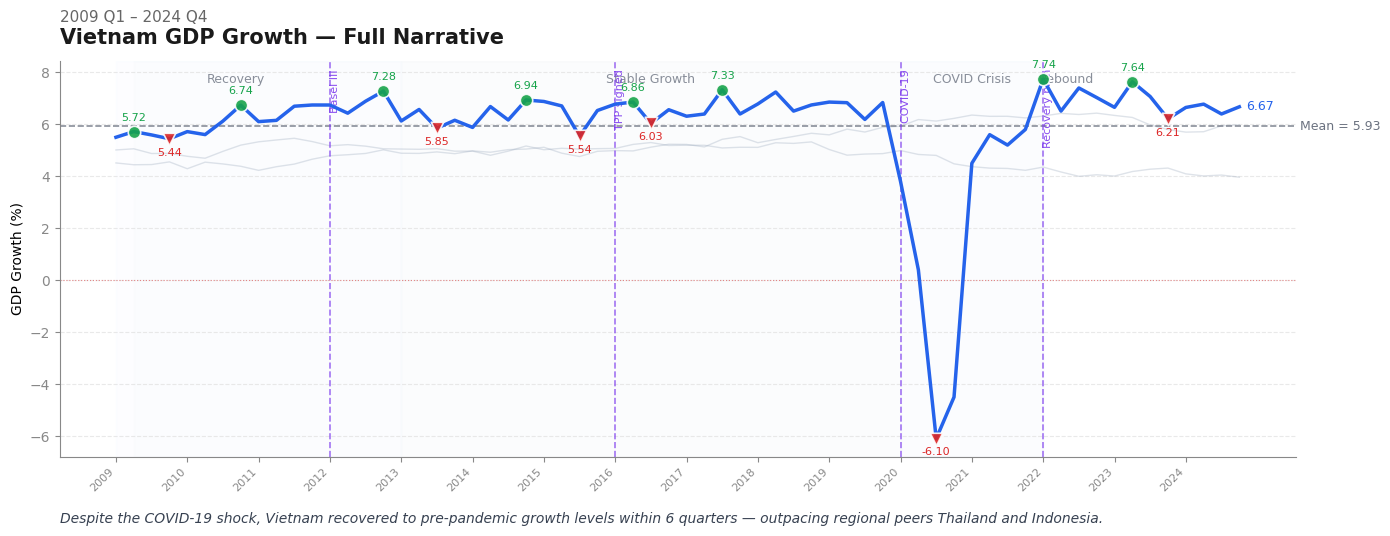

In [11]:
# Background: 2 nước khác trong khu vực (simulated)
rng = np.random.default_rng(99)
bg_series = {
    'Thailand': 4.5 + np.cumsum(rng.normal(0, 0.15, n_quarters)),
    'Indonesia': 5.0 + np.cumsum(rng.normal(0, 0.13, n_quarters)),
}

chart = (
    NarrativePipeline(
        x=quarters,
        y=y_gdp,
        title='Vietnam GDP Growth — Full Narrative',
        subtitle='2009 Q1 – 2024 Q4',
        figsize=(14, 5.5),
        signal_color='#2563EB',
    )
    .add_regimes(
        breakpoints=BREAKPOINTS,
        labels=REGIME_LABELS,
    )
    .add_background(bg_series)
    .add_events(EVENTS)
    .add_turning_points()
    .add_mean_reference()
    .add_caption(
        'Despite the COVID-19 shock, Vietnam recovered to pre-pandemic growth levels '
        'within 6 quarters — outpacing regional peers Thailand and Indonesia.'
    )
    .run()
)

ax = chart.ax
ax.set_xticks(year_ticks)
ax.set_xticklabels(year_labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('GDP Growth (%)')
ax.axhline(0, color='#DC2626', linewidth=0.8, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()

Biểu đồ này minh họa **NarrativePipeline hoàn chỉnh**, nơi tất cả narrative layers được kết hợp trong một visualization duy nhất.

Pipeline layering:

Regime shading
→ Background series
→ Signal series
→ Mean reference
→ Turning points
→ Event markers
→ Caption

---

## Regime Context

Timeline được chia thành các regimes:

Recovery:

$$
R_1 = [2009, 2011]
$$

Stable growth:

$$
R_2 = [2012, 2019]
$$

COVID crisis:

$$
R_3 = [2020, 2021]
$$

Rebound:

$$
R_4 = [2022, 2024]
$$

Regime shading cung cấp:

$$
structural\ context
$$

---

## Background vs Signal

Background series (faded):

$$
x_t^{bg}
$$

Signal series (highlighted):

$$
x_t
$$

Tạo visual hierarchy:

$$
signal > background
$$

Giúp focus vào:

- turning points
- anomalies
- regime shifts

---

## Mean Reference

Đường mean:

$$
\mu = 5.93
$$

So sánh:

Peak:

$$
7.74 > 5.93
$$

Trough:

$$
-6.10 < 5.93
$$

Deviation:

$$
x_t - \mu
$$

Giúp đánh giá:

- above trend
- below trend

---

## Turning Points

Local peaks:

$$
7.28,\ 6.94,\ 7.33,\ 7.74,\ 7.64
$$

Local troughs:

$$
5.44,\ 5.85,\ 5.54,\ -6.10,\ 6.21
$$

Turning points xác định:

$$
trend\ reversals
$$

---

## Event Markers

Vertical markers:

- Brexit
- TPP signing
- COVID-19
- Recovery

Mapping:

$$
event \rightarrow structural\ change
$$

COVID marker trùng:

$$
x_{min} = -6.10
$$

---

## Caption Insight

Caption:

Vietnam recovered within:

$$
6\ quarters
$$

Sau shock:

$$
-6.1\%
$$

Recovery:

$$
x_t \rightarrow 7\%
$$

Insight:

- fast recovery
- resilience
- outperform peers

---

## Full Narrative Flow

Pipeline kể câu chuyện:

Recovery:

$$
5.5 \rightarrow 7.2
$$

Stable growth:

$$
6\% \sim 7\%
$$

Shock:

$$
-6.1\%
$$

Rebound:

$$
7.7\%
$$

Narrative:

$$
Recovery \rightarrow Stability \rightarrow Shock \rightarrow Rebound
$$

---

## Layer Interaction

Regime shading:

$$
structure
$$

Signal:

$$
data
$$

Turning points:

$$
events\ in\ data
$$

Event markers:

$$
external\ events
$$

Caption:

$$
insight
$$

Combined:

$$
full\ narrative
$$

---

## Key Takeaways

NarrativePipeline tạo:

- structural context
- highlighted signal
- mean reference
- turning points
- event markers
- final insight

Pipeline:

$$
data \rightarrow story
$$

Visualization trở thành:

$$
storytelling\ chart
$$

## 9. Comparing Narrative Depth

Cùng một dataset có thể được trình bày với **mức độ narrative khác nhau**.
Narrative depth càng cao → insight càng rõ → người xem hiểu nhanh hơn.

Ba mức độ phổ biến:

- Level 0 — Raw chart
- Level 1 — Events + turning points
- Level 2 — Regimes + events + turning points + caption

---

## Level 0 — Raw Chart

Chỉ vẽ:

$$
x_t
$$

Không có:

- regimes
- events
- annotations
- caption

Người xem phải tự suy luận:

- turning point ở đâu
- shock khi nào
- recovery thế nào

Visualization chỉ thể hiện:

$$
data\ only
$$

Insight:

$$
implicit
$$

---

## Level 1 — Events + Turning Points

Thêm:

Turning points:

$$
\{t_{tp}\}
$$

Event markers:

$$
\{t_e\}
$$

Visualization trở thành:

$$
data + structure
$$

Người xem thấy:

- peaks
- troughs
- reversal
- event timing

Insight:

$$
semi\ explicit
$$

---

## Level 2 — Full Narrative

Thêm:

Regimes:

$$
R_1, R_2, R_3
$$

Caption:

$$
global\ insight
$$

Visualization:

$$
data + structure + explanation
$$

Người xem hiểu ngay:

- regimes
- shock
- recovery
- takeaway

Insight:

$$
explicit
$$

---

## Information Hierarchy

Level 0:

$$
data
$$

Level 1:

$$
data + events
$$

Level 2:

$$
data + events + narrative
$$

Information content:

$$
Level\ 2 > Level\ 1 > Level\ 0
$$

---

## Cognitive Load

Level 0:

$$
high\ cognitive\ load
$$

Level 1:

$$
medium
$$

Level 2:

$$
low
$$

Narrative giúp giảm:

- interpretation time
- ambiguity
- confusion

---

## Example Interpretation

Level 0:

Người xem tự nhận ra drop.

Level 1:

Người xem thấy:

$$
COVID \rightarrow drop
$$

Level 2:

Người xem hiểu:

COVID gây drop nhưng recovery nhanh.

---

## Narrative Evolution

Level 0:

$$
plot(x_t)
$$

Level 1:

$$
plot + events + turning\ points
$$

Level 2:

$$
plot + regimes + events + turning + caption
$$

---

## Summary

Level 0:

- raw data
- no narrative

Level 1:

- events
- turning points

Level 2:

- regimes
- events
- turning points
- caption

Narrative depth:

$$
0 \rightarrow 1 \rightarrow 2
$$

Insight clarity:

$$
increase
$$

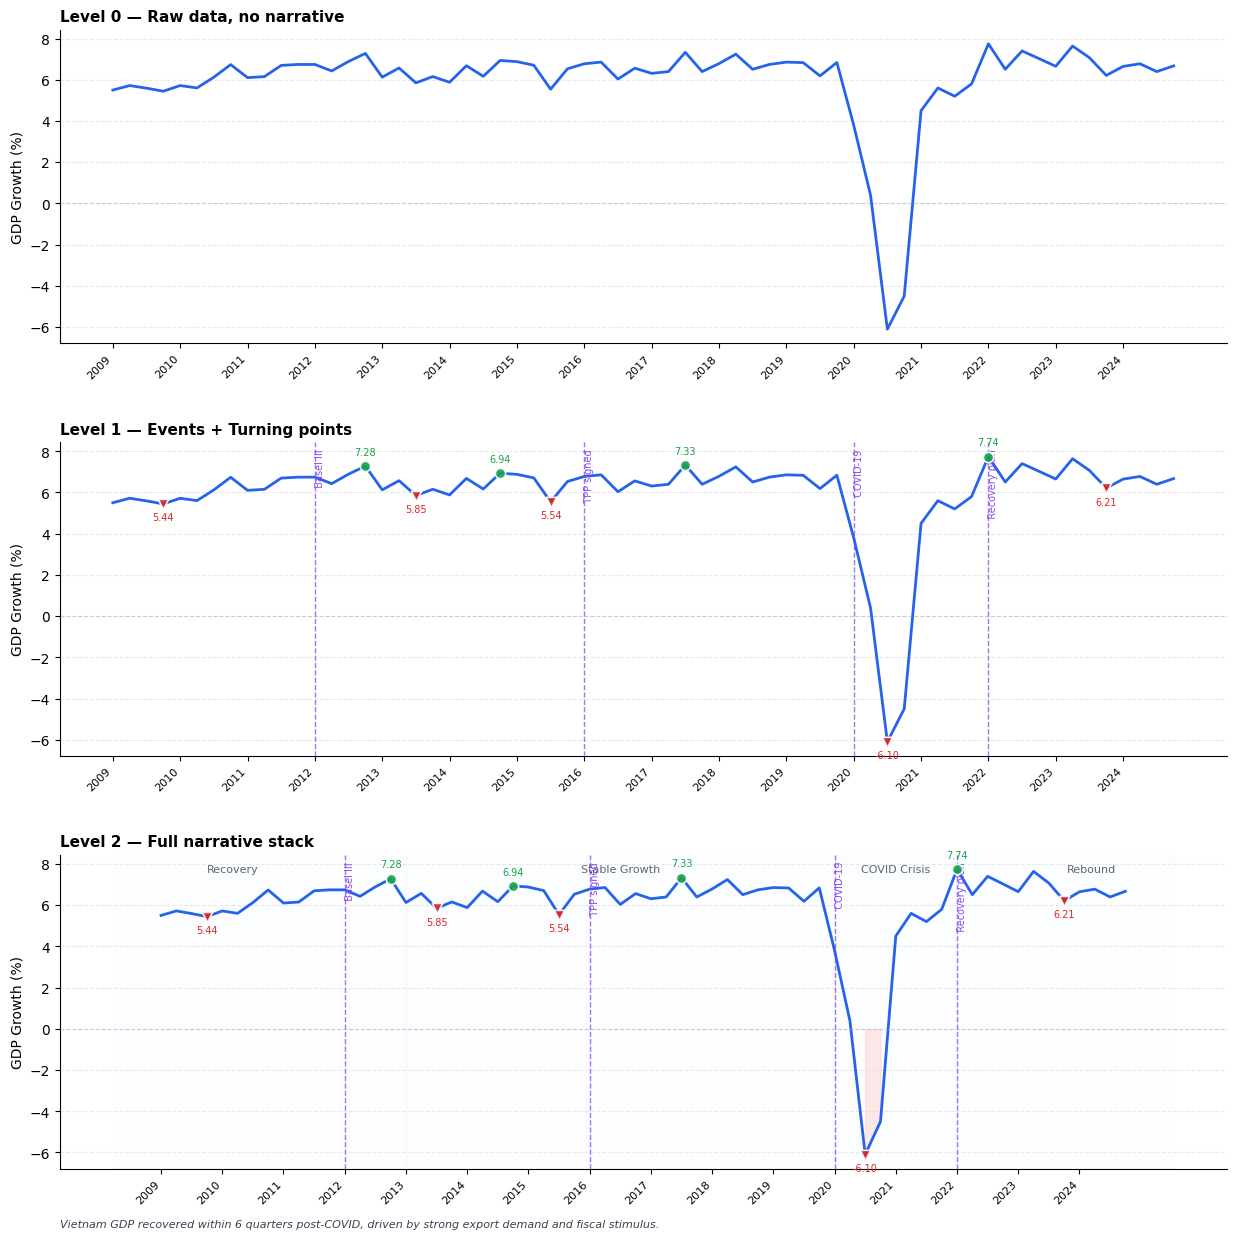

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(13, 13), facecolor='white')
titles = [
    'Level 0 — Raw data, no narrative',
    'Level 1 — Events + Turning points',
    'Level 2 — Full narrative stack',
]

for level, (ax, title) in enumerate(zip(axes, titles)):
    # Base: always plot the series
    ax.plot(quarters, y_gdp, color='#2563EB', linewidth=2.0)
    ax.axhline(0, color='#9CA3AF', linewidth=0.8, linestyle='--', alpha=0.4)

    if level >= 1:
        # Add events and turning points
        add_event_markers(ax, [x for x, _ in EVENTS],
                          labels=[l for _, l in EVENTS],
                          color='#7C3AED', linewidth=1.0, label_fontsize=7)
        mark_turning_points(ax, quarters, y_gdp, order=6,
                            max_color='#16A34A', min_color='#DC2626',
                            show_labels=True, label_fontsize=7, size=55)

    if level >= 2:
        # Add regimes + labels + caption
        shade_regimes(ax, BREAKPOINTS, alpha=0.15)
        add_regime_labels(ax, BREAKPOINTS, REGIME_LABELS, fontsize=8, color='#374151')
        ax.fill_between(quarters, y_gdp, 0,
                        where=(y_gdp < 0), color='#FECACA', alpha=0.4)
        add_narrative_caption(
            ax,
            'Vietnam GDP recovered within 6 quarters post-COVID, '
            'driven by strong export demand and fiscal stimulus.',
            y=-0.16, fontsize=8
        )

    ax.set_xticks(year_ticks)
    ax.set_xticklabels(year_labels, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('GDP Growth (%)')
    ax.set_title(title, loc='left', fontsize=11, fontweight='bold')
    despine(ax); set_grid(ax)

plt.tight_layout(pad=3.0)
plt.show()

Cùng một dataset có thể được trình bày với **mức độ narrative khác nhau**.
Narrative depth càng cao → insight càng rõ → người xem hiểu nhanh hơn.

Ba mức độ phổ biến:

- Level 0 — Raw chart
- Level 1 — Events + turning points
- Level 2 — Regimes + events + turning points + caption

---

## Level 0 — Raw Chart

Chỉ vẽ:

$$
x_t
$$

Không có:

- regimes
- events
- annotations
- caption

Người xem phải tự suy luận:

- turning point ở đâu
- shock khi nào
- recovery thế nào

Visualization chỉ thể hiện:

$$
data\ only
$$

Insight:

$$
implicit
$$

---

## Level 1 — Events + Turning Points

Thêm:

Turning points:

$$
\{t_{tp}\}
$$

Event markers:

$$
\{t_e\}
$$

Visualization trở thành:

$$
data + structure
$$

Người xem thấy:

- peaks
- troughs
- reversal
- event timing

Insight:

$$
semi\ explicit
$$

---

## Level 2 — Full Narrative

Thêm:

Regimes:

$$
R_1, R_2, R_3
$$

Caption:

$$
global\ insight
$$

Visualization:

$$
data + structure + explanation
$$

Người xem hiểu ngay:

- regimes
- shock
- recovery
- takeaway

Insight:

$$
explicit
$$

---

## Information Hierarchy

Level 0:

$$
data
$$

Level 1:

$$
data + events
$$

Level 2:

$$
data + events + narrative
$$

Information content:

$$
Level\ 2 > Level\ 1 > Level\ 0
$$

---

## Cognitive Load

Level 0:

$$
high\ cognitive\ load
$$

Level 1:

$$
medium
$$

Level 2:

$$
low
$$

Narrative giúp giảm:

- interpretation time
- ambiguity
- confusion

---

## Example Interpretation

Level 0:

Người xem tự nhận ra drop.

Level 1:

Người xem thấy:

$$
COVID \rightarrow drop
$$

Level 2:

Người xem hiểu:

COVID gây drop nhưng recovery nhanh.

---

## Narrative Evolution

Level 0:

$$
plot(x_t)
$$

Level 1:

$$
plot + events + turning\ points
$$

Level 2:

$$
plot + regimes + events + turning + caption
$$

---

## Summary

Level 0:

- raw data
- no narrative

Level 1:

- events
- turning points

Level 2:

- regimes
- events
- turning points
- caption

Narrative depth:

$$
0 \rightarrow 1 \rightarrow 2
$$

Insight clarity:

$$
increase
$$

---
## Summary

| Technique | Function | Khi nào dùng |
|-----------|----------|-------------|
| Turning points | `mark_turning_points` | Tự động đánh dấu đỉnh/đáy |
| Event marker | `add_event_markers` | Gắn sự kiện vào thời điểm cụ thể |
| Timeline band | `add_timeline_band` | Giai đoạn kéo dài có tên |
| Regime shading | `shade_regimes` | Phân vùng hệ thống xen kẽ |
| Regime labels | `add_regime_labels` | Tên cho từng regime |
| Story frames | `StoryFrame` | Cấu trúc hóa narrative thành objects |
| Narrative caption | `add_narrative_caption` | Takeaway text dưới chart |
| Arrow annotation | `annotate_with_arrow` | Giải thích điểm dữ liệu cụ thể |
| Full pipeline | `NarrativePipeline` | One-call storytelling chart |

---

### Key Takeaway

> Narrative không phải là thêm chữ vào chart.
> Narrative là **cấu trúc hóa thông tin** để người xem hiểu *khi nào*, *tại sao*, và *ý nghĩa là gì* — không cần phải đọc thêm bất kỳ tài liệu nào khác.

**Next →** `03_context_and_comparison.ipynb` — Số liệu chỉ có ý nghĩa khi có ngưỡng tham chiếu: benchmark, target, và so sánh trực tiếp.